In [2]:
from libraries import *
from parameters import *
from util import *
from itertools import combinations
#from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics.pairwise import cosine_similarity


/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/beraslan", R: "/home/beraslan/Projects/ChemoGeneticScreens"
  warnings.warn(
/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/tmp/Rtmpwy2GeC", R: "/tmp/Rtmp6Qqnq4"
  warnings.warn(
/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import pdex
print(pdex.__version__)

ModuleNotFoundError: No module named 'pdex'

In [189]:
df = pd.read_csv("./TextFiles/Giant_FC_matrix_genes_by_contextPerturbation.csv", index_col=0)
df=np.transpose(df)

In [190]:
def build_perturbation_conditionpair_jaccard(
    df: pd.DataFrame,
    index_sep: str = "__"
) -> pd.DataFrame:
    """
    Compute Jaccard distance between DE gene sets of the same perturbation 
    across condition pairs.

    Parameters
    ----------
    df : pd.DataFrame
        Rows indexed as 'condition__perturbation', columns = response genes
        Values = percent change (nonzero means DE).
    index_sep : str
        Separator between condition and perturbation in the row index.

    Returns
    -------
    pd.DataFrame
        Rows: perturbations
        Columns: 'condA__vs__condB'
        Values: Jaccard distance (1 - Jaccard similarity)
                Missing pairs → 1.0
    """

    gene_cols = df.columns.tolist()

    # --- Split index ---
    idx_split = df.index.to_series().str.split(index_sep, n=1, expand=True)
    if idx_split.shape[1] != 2:
        raise ValueError(f"Index must split into 2 using '{index_sep}'")

    df = df.copy()
    df["condition"] = idx_split[0].values
    df["perturbation"] = idx_split[1].values

    conditions = sorted(df["condition"].unique())
    cond_pairs = list(combinations(conditions, 2))
    pair_names = [f"{c1}__vs__{c2}" for c1, c2 in cond_pairs]

    results = []

    # -------------------------------------------------
    # Iterate over each perturbation
    # -------------------------------------------------
    for pert, sub in df.groupby("perturbation"):

        # Build condition x gene matrix
        mat = (
            sub.set_index("condition")[gene_cols]
               .reindex(conditions)
        )

        # For each condition: find DE genes = nonzero entries
        de_sets = {}
        for cond in conditions:
            row = mat.loc[cond]
            if not row.isna().all():
                de_sets[cond] = set(row.index[row != 0])
            else:
                de_sets[cond] = None  # mark missing

        # If <2 non-missing conditions → distances default to 1
        if sum(v is not None for v in de_sets.values()) < 2:
            results.append([pert] + [1.0] * len(cond_pairs))
            continue

        row_vals = []

        # -------------------------------------------------
        # Compute Jaccard for each condition pair
        # -------------------------------------------------
        for c1, c2 in cond_pairs:
            s1, s2 = de_sets[c1], de_sets[c2]

            if s1 is None or s2 is None:
                d = -1.0  # missing → max distance
            else:
                inter = len(s1 & s2)
                union = len(s1 | s2)
                if union == 0:
                    d = -1.0
                else:
                    jaccard_sim = inter / union
                    d = jaccard_sim

            row_vals.append(d)

        results.append([pert] + row_vals)

    out_df = pd.DataFrame(results, columns=["perturbation"] + pair_names)
    out_df = out_df.set_index("perturbation")

    return out_df


In [191]:
jaccardSims=build_perturbation_conditionpair_jaccard(df)

In [192]:
jaccardSims.to_csv("JaccardSims.csv")

In [200]:
respAnnDat = sc.AnnData(X=df.copy())
sc.pp.scale(respAnnDat)
sc.pp.pca(respAnnDat, n_comps=1000, svd_solver='arpack')


In [201]:
sum(respAnnDat.uns['pca']['variance_ratio'])

np.float64(0.579093162942637)

In [198]:
df

,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,AADACL2,...,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,bfp,dCas9,gfp
AR-A014418__ACOT9,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
AR-A014418__ACVR1B,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.084054,0.0,0.000000
AR-A014418__ACVR2A,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
AR-A014418__ADAR,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.074109,0.0,0.040199
AR-A014418__ADI1,0.0,0.0,0.192699,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,-0.191729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Romidepsin__ZNHIT3,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
Romidepsin__ZRSR2,0.0,0.0,0.000000,0.0,0.0,0.0,-0.395109,0.000000,0.0,0.0,...,0.0,0.000000,3.001933,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.433952
Romidepsin__ZW10,0.0,0.0,0.000000,0.0,0.0,0.0,-0.482723,0.000000,0.0,0.0,...,0.0,0.952172,2.162185,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.447549
Romidepsin__ZXDC,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.167183,0.0,0.0,...,0.0,-0.953171,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000


In [202]:
my_Xpca= pd.DataFrame(respAnnDat.obsm['X_pca'])
my_Xpca.index=respAnnDat.obs.index

In [203]:
my_Xpca

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
AR-A014418__ACOT9,9.714999,-0.565500,-3.019233,0.136909,-0.771204,1.017823,-0.735817,0.600284,0.335824,-0.050998,...,0.235892,-0.189399,0.445402,0.095381,-0.409944,0.029114,0.356304,0.156594,-0.005879,-0.061094
AR-A014418__ACVR1B,10.240014,-1.170810,-2.688142,0.583658,-0.841502,1.079775,-0.674056,1.327824,0.154187,0.412093,...,0.049590,0.106855,-0.014880,0.083334,0.067714,-0.348081,-0.050847,-0.193596,-0.331013,-0.264710
AR-A014418__ACVR2A,9.610555,-0.620323,-3.073544,-0.090319,-0.965275,0.447409,-0.982335,0.527421,0.264751,0.015576,...,-0.181983,0.003722,-0.122856,0.166310,-0.194403,0.105433,-0.221081,0.067589,-0.055491,-0.323508
AR-A014418__ADAR,10.812082,-0.339436,-2.851947,-0.748256,1.241874,1.601983,-0.299409,-0.513883,0.199045,0.153212,...,-0.079249,-0.250266,-0.423375,0.176400,0.380800,-0.323228,-0.008777,-0.022362,0.190074,0.137004
AR-A014418__ADI1,10.143176,-0.762201,-2.535186,0.136417,0.170362,0.877055,-0.744835,1.029175,0.302028,0.175446,...,0.059418,0.079533,-0.124179,0.267438,0.171432,0.070216,-0.226232,-0.119197,-0.104309,-0.215087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Romidepsin__ZNHIT3,8.827573,6.240181,21.073231,-4.114231,-3.687135,-7.505135,25.925119,-4.922439,-2.633595,1.255341,...,3.924052,-8.558274,-8.008260,2.230319,6.184252,-12.093425,-11.403972,2.177117,2.797971,-3.791471
Romidepsin__ZRSR2,-221.009521,-26.215315,18.080004,-35.470669,33.849812,-38.323750,-2.442651,-4.865477,31.386909,-64.980705,...,-15.288045,-5.676764,12.910668,5.209623,3.750013,10.087293,-6.618087,-1.387481,-2.966052,-3.770257
Romidepsin__ZW10,-273.576630,-17.282898,20.638035,14.717768,54.140247,-2.277426,-22.855162,-33.536896,-34.488331,46.169827,...,10.013288,-0.842089,9.685687,0.690144,-6.250870,13.026292,4.915595,-4.376926,-3.390713,7.758740
Romidepsin__ZXDC,-4.025732,-2.398253,-0.252932,1.276982,7.166524,-1.276737,-6.079783,-2.772405,-5.234345,6.224527,...,-0.052308,0.031991,0.796880,-0.096794,-0.177212,-1.078685,-0.037377,0.572606,-1.036764,-0.068394


In [213]:
def build_perturbation_conditionpair_cosine(
    df: pd.DataFrame,
    index_sep: str = "__"
) -> pd.DataFrame:
    """
    Parameters
    ----------
    df : pd.DataFrame
        Rows indexed as 'condition__perturbation', columns are response genes.
    index_sep : str
        Separator between condition and perturbation in the index.

    Returns
    -------
    pd.DataFrame
        Rows: perturbations
        Columns: 'condA__vs__condB'
        Values: cosine distance between that perturbation's profiles 
                in the two conditions.
                Missing pairs are assigned distance = 1.0.
    """
    gene_cols = df.columns.tolist()

    # Split index into condition + perturbation
    idx_split = df.index.to_series().str.split(index_sep, n=1, expand=True)
    if idx_split.shape[1] != 2:
        raise ValueError(
            f"Index could not be split into 2 parts using separator {index_sep}"
        )

    df = df.copy()
    df["condition"] = idx_split[0].values
    df["perturbation"] = idx_split[1].values

    conditions = sorted(df["condition"].unique())
    cond_pairs = list(combinations(conditions, 2))
    pair_names = [f"{c1}__vs__{c2}" for c1, c2 in cond_pairs]

    results = []

    # Iterate over each perturbation
    for pert, sub in df.groupby("perturbation"):
        # Build condition × gene matrix for this perturbation
        mat = (
            sub
            .set_index("condition")[gene_cols]
            .reindex(conditions)  # ensures consistency
        )

        # Conditions that have data
        present_mask = ~mat.isna().all(axis=1)
        present_conditions = mat.index[present_mask]

        # If fewer than 2 conditions with data → all distances = 1.0
        if len(present_conditions) < 2:
            row_vals = [-10] * len(cond_pairs)
            results.append([pert] + row_vals)
            continue

        # Compute cosine distance between present condition vectors
        X = mat.loc[present_conditions].values
        cos_mat = cosine_distances(X)

        # Map condition → row in cosine matrix
        pos = {c: i for i, c in enumerate(present_conditions)}

        # Fill each pair – missing pair → distance = 1.0
        row_vals = []
        for c1, c2 in cond_pairs:
            if c1 in pos and c2 in pos:
                d = float(cos_mat[pos[c1], pos[c2]])
            else:
                d = -10  # default when missing
            row_vals.append(d)

        results.append([pert] + row_vals)

    # Build final output DF
    out_df = pd.DataFrame(results, columns=["perturbation"] + pair_names)
    out_df = out_df.set_index("perturbation")
    return out_df


In [204]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity


def build_perturbation_conditionpair_cosine_similarity(
    df: pd.DataFrame,
    index_sep: str = "__"
) -> pd.DataFrame:
    """
    Parameters
    ----------
    df : pd.DataFrame
        Rows indexed as 'condition__perturbation', columns are response genes.
    index_sep : str
        Separator between condition and perturbation in the index.

    Returns
    -------
    pd.DataFrame
        Rows: perturbations
        Columns: 'condA__vs__condB'
        Values: cosine *similarity* between that perturbation's profiles 
                in the two conditions.
                Missing pairs are assigned similarity = -10 (sentinel).
    """
    gene_cols = df.columns.tolist()

    # Split index into condition + perturbation
    idx_split = df.index.to_series().str.split(index_sep, n=1, expand=True)
    if idx_split.shape[1] != 2:
        raise ValueError(
            f"Index could not be split into 2 parts using separator {index_sep}"
        )

    df = df.copy()
    df["condition"] = idx_split[0].values
    df["perturbation"] = idx_split[1].values

    conditions = sorted(df["condition"].unique())
    cond_pairs = list(combinations(conditions, 2))
    pair_names = [f"{c1}__vs__{c2}" for c1, c2 in cond_pairs]

    results = []

    # Iterate over each perturbation
    for pert, sub in df.groupby("perturbation"):
        # Build condition × gene matrix for this perturbation
        mat = (
            sub
            .set_index("condition")[gene_cols]
            .reindex(conditions)  # ensures consistency
        )

        # Conditions that have data
        present_mask = ~mat.isna().all(axis=1)
        present_conditions = mat.index[present_mask]

        # If fewer than 2 conditions with data → all similarities = sentinel
        if len(present_conditions) < 2:
            row_vals = [-10] * len(cond_pairs)
            results.append([pert] + row_vals)
            continue

        # Compute cosine *similarity* between present condition vectors
        X = mat.loc[present_conditions].values
        cos_sim_mat = cosine_similarity(X)  # shape: (n_present, n_present)

        # Map condition → row in cosine matrix
        pos = {c: i for i, c in enumerate(present_conditions)}

        # Fill each pair – missing pair → similarity = -10
        row_vals = []
        for c1, c2 in cond_pairs:
            if c1 in pos and c2 in pos:
                s = float(cos_sim_mat[pos[c1], pos[c2]])
            else:
                s = -10  # sentinel for missing
            row_vals.append(s)

        results.append([pert] + row_vals)

    # Build final output DF
    out_df = pd.DataFrame(results, columns=["perturbation"] + pair_names)
    out_df = out_df.set_index("perturbation")
    return out_df


In [214]:
out_df = build_perturbation_conditionpair_cosine(my_Xpca)

In [215]:
out_df

,AR-A014418__vs__AZD4573,AR-A014418__vs__CHIR,AR-A014418__vs__CHIR-98014,AR-A014418__vs__DMSO,AR-A014418__vs__DMSO_round2,AR-A014418__vs__KYA,AR-A014418__vs__LDN,AR-A014418__vs__Lexibulin,AR-A014418__vs__PFI1,AR-A014418__vs__PP121,...,Lexibulin__vs__PFI1,Lexibulin__vs__PP121,Lexibulin__vs__RGFP,Lexibulin__vs__Romidepsin,PFI1__vs__PP121,PFI1__vs__RGFP,PFI1__vs__Romidepsin,PP121__vs__RGFP,PP121__vs__Romidepsin,RGFP__vs__Romidepsin
perturbation,,,,,,,,,,,,,,,,,,,,,
A1BG,0.026520,0.044836,0.053655,0.025876,0.029570,0.035624,0.046055,0.024676,0.044583,0.030250,...,0.036064,0.022918,0.024030,0.023902,0.037065,0.039012,0.042739,0.028326,0.031984,0.032119
AASS,0.111093,0.203167,0.179226,0.119619,0.109294,0.129845,0.134611,0.103257,0.200736,0.126928,...,0.187501,0.102581,0.106790,0.080417,0.189066,0.183613,0.166196,0.110559,0.079275,0.083389
AATF,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,...,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,1.011664
ABCB6,0.072940,0.775571,0.847094,0.082281,0.096136,0.101711,0.096724,0.063870,0.082665,0.067840,...,0.057131,0.051875,0.058905,0.053424,0.065828,0.072226,0.070642,0.063472,0.060612,0.066875
ABCC5,0.048066,0.158459,0.087244,0.034856,0.045017,0.046955,0.045713,0.046675,0.052851,0.058621,...,0.054554,0.055026,0.048242,0.052135,0.064470,0.058487,0.069235,0.063140,0.067874,0.067722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSCAN29,0.049123,0.379014,0.067925,0.152912,0.051626,0.162946,0.210015,0.041017,0.168077,0.052738,...,0.153463,0.047238,0.145122,0.038798,0.167974,0.234565,0.160951,0.162469,0.053667,0.155081
ZSCAN32,0.307600,1.106894,0.801048,0.348578,0.533923,0.291782,0.364376,0.240047,0.608418,0.583494,...,0.444011,0.448196,0.093763,0.184244,0.443359,0.409382,0.375289,0.442332,0.410574,0.190842
ZW10,0.389174,0.989338,1.003004,0.469999,0.450191,0.368836,0.562613,0.265936,0.885617,0.481028,...,0.779558,0.343650,0.326474,0.121507,0.897168,0.867107,0.790753,0.408320,0.365556,0.318163


In [216]:
tmp = out_df.copy()
respAnnDat = sc.AnnData(X=tmp)
respAnnDat.obs["pertIndex"] = list(tmp.index)
sc.pp.neighbors(respAnnDat, n_neighbors=5)
sc.tl.leiden(respAnnDat, resolution=1)
sc.tl.umap(respAnnDat)


/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 78 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


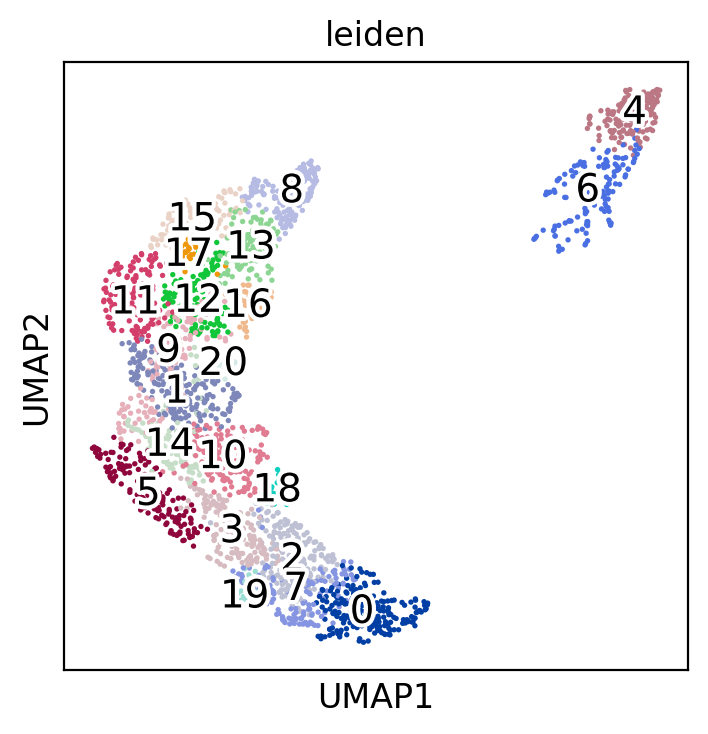

In [217]:
sc.pl.umap(respAnnDat, 
           color='leiden',
           size=15,  
           legend_fontoutline=3, 
           legend_loc = 'on data',
           legend_fontsize=14,
           legend_fontweight='normal')


In [ ]:
0,7,2,19,3,18,10,5,14,1,20,9,11,12,16,17,13,15,8,6,4

In [ ]:
3,12,1,13,11,7,14,6,0,18,10,2,17,15,16,9,4,19,8,5

In [218]:
out_df["leiden"]=respAnnDat.obs["leiden"]
out_df["leiden"] = pd.Categorical(
    out_df["leiden"],
    # categories=['3','12',
    #             '1','13',
    #             '11','7','14','6',
    #             '0','18','10','2',
    #             '17','15','16',
    #             '9','4','19','8','5'],
    categories=['0','7','2',
             '19','3','18','10',
             '5','14','1','20','9','11',
             '12','16','17','13','15','8',
             '6','4'],
    ordered=True
)

# then sort by this ordered column
out_df = out_df.sort_values("leiden")

In [219]:
out_df

,AR-A014418__vs__AZD4573,AR-A014418__vs__CHIR,AR-A014418__vs__CHIR-98014,AR-A014418__vs__DMSO,AR-A014418__vs__DMSO_round2,AR-A014418__vs__KYA,AR-A014418__vs__LDN,AR-A014418__vs__Lexibulin,AR-A014418__vs__PFI1,AR-A014418__vs__PP121,...,Lexibulin__vs__PP121,Lexibulin__vs__RGFP,Lexibulin__vs__Romidepsin,PFI1__vs__PP121,PFI1__vs__RGFP,PFI1__vs__Romidepsin,PP121__vs__RGFP,PP121__vs__Romidepsin,RGFP__vs__Romidepsin,leiden
perturbation,,,,,,,,,,,,,,,,,,,,,
A1BG,0.026520,0.044836,0.053655,0.025876,0.029570,0.035624,0.046055,0.024676,0.044583,0.030250,...,0.022918,0.024030,0.023902,0.037065,0.039012,0.042739,0.028326,0.031984,0.032119,0
PBX3,0.049308,0.134266,0.055845,0.058500,0.058942,0.060005,0.049000,0.052838,0.071318,0.049979,...,0.052180,0.060643,0.066004,0.074538,0.080629,0.085602,0.053809,0.057639,0.063791,0
PAFAH1B2,0.054753,0.071093,0.057979,0.046335,0.049341,0.049170,0.055660,0.039436,0.053210,0.054601,...,0.048459,0.049420,0.037527,0.062924,0.055600,0.056478,0.061796,0.056435,0.059679,0
OSBPL1A,0.044767,0.078768,0.076518,0.039653,0.043030,0.057680,0.051250,0.046413,0.077883,0.041932,...,0.044033,0.056844,0.042789,0.070818,0.079764,0.073050,0.049789,0.046232,0.054151,0
NUDT9,0.048197,0.091695,0.062185,0.050861,0.069120,0.050684,0.059556,0.043705,0.062951,0.050814,...,0.036543,0.051212,0.042641,0.055622,0.069047,0.065029,0.059870,0.053051,0.065182,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RPS11,0.857281,-10.000000,0.930876,0.916227,-10.000000,-10.000000,-10.000000,0.903811,-10.000000,0.980664,...,0.979599,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,4
MED10,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,...,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,4
RPL37A,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,...,0.800411,-10.000000,-10.000000,0.927181,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,4


In [220]:
out_df.to_csv("PerturbationClusters_v3.csv")